In [82]:
import pandas as pd
import matplotlib. pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [83]:
lung_data = pd.read_csv("survey lung cancer.csv")

In [84]:
lung_data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [85]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [86]:
lung_data.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [87]:
#dependent_variable 
x = lung_data.iloc[:,0:-1] 
print(x)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                  1        2        1         2                  2         2   
1                  2 

In [88]:
#independent_variable
y = lung_data. iloc[:,-1:]
print(y)

    LUNG_CANCER
0           YES
1           YES
2            NO
3            NO
4            NO
..          ...
304         YES
305         YES
306         YES
307         YES
308         YES

[309 rows x 1 columns]


In [89]:
lung_data.GENDER = lung_data.GENDER.map({"M":1,"F":2})
lung_data.LUNG_CANCER = lung_data.LUNG_CANCER.map({"YES":1,"NO":2})

In [90]:
lung_data.shape

(309, 16)

In [91]:
lung_data.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [92]:
lung_data.dtypes

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
LUNG_CANCER              int64
dtype: object

In [93]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,2,59,1,1,1,2,1,2,1,2,1,2,2,1,2,2
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,2
4,2,63,1,2,1,1,1,1,1,2,1,2,2,1,1,2


In [94]:
lung_data.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,2,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1
308,1,62,1,1,1,2,1,2,2,2,2,1,1,2,1,1


In [95]:
#the describe() method returns description of data in DataFrame
lung_data.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,1.475728,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634,1.126214
std,0.500221,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,0.332629
min,1.000000,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000
75%,2.000000,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,2.000000,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [96]:
#the info() method prints information of the database
lung_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int64
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

In [97]:
#Splitting the Dataset: Training and Testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=1/3,random_state=0)

In [98]:
lung_data['LUNG_CANCER'].value_counts()

LUNG_CANCER
1    270
2     39
Name: count, dtype: int64

In [99]:
len(lung_data)

309

In [100]:
len(x_test)

103

In [101]:
len(x_train)

206

In [102]:
#dependent_variable
x = lung_data.iloc[:,0:-1]
x

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2
2,2,59,1,1,1,2,1,2,1,2,1,2,2,1,2
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2
4,2,63,1,2,1,1,1,1,1,2,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,2,56,1,1,1,2,2,2,1,1,2,2,2,2,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2


In [103]:
#independent_variable
y = lung_data.iloc[:,-1:] 
y

,LUNG_CANCER
0,1
1,1
2,2
3,2
4,2
...,...
304,1
305,1
306,1
307,1


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [105]:
from sklearn.linear_model import LogisticRegression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=1/3,random_state=0)

Logistic Regression

In [106]:
#Fitting simple linear regression to the training test
Model1 = LogisticRegression()
Model1.fit(x_train, y_train)
#Predicting the test set results
prediction1 = Model1.predict(x_test)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [107]:
prediction1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [108]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction1)

array([[85,  2],
       [10,  6]])

In [109]:
 accuracy_score(y_test,prediction1)

0.883495145631068

In [110]:
from sklearn.metrics import precision_score
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction1, average = None)

array([0.89473684, 0.75      ])

In [111]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction1)
precision = precision_score(y_test, prediction1)
recall = recall_score(y_test, prediction1)
f1 = f1_score(y_test, prediction1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.883495145631068
Precision: 0.8947368421052632
Recall: 0.9770114942528736
F1 score: 0.9340659340659341


In [112]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [113]:
recall_score(y_test, prediction1, average = None)

array([0.97701149, 0.375     ])

In [114]:
 f1_score(y_test, prediction1, average = None)

array([0.93406593, 0.5       ])

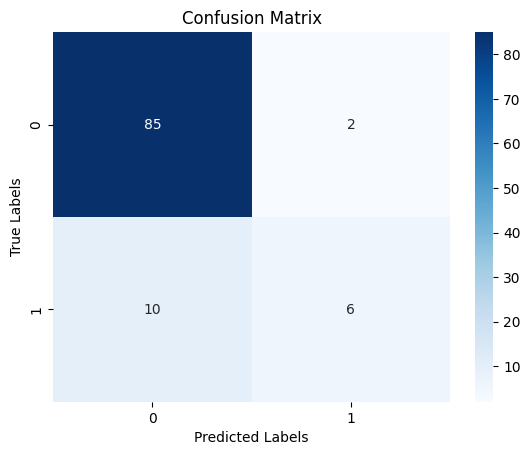

In [115]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction1)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

KNN

In [116]:
 from sklearn.neighbors import KNeighborsClassifier

In [117]:
#Fitting K-NN to the Training set
classifier = KNeighborsClassifier(n_neighbors = 3, metric = "minkowski", p = 2)
classifier.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [118]:
#Predicting the Test set result
prediction2 = classifier.predict(x_test)

In [119]:
prediction2

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [120]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction2)

array([[85,  2],
       [13,  3]])

In [121]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction2)
precision = precision_score(y_test, prediction2)
recall = recall_score(y_test, prediction2)
f1 = f1_score(y_test, prediction2)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8543689320388349
Precision: 0.8673469387755102
Recall: 0.9770114942528736
F1 score: 0.918918918918919


In [122]:
accuracy_score(y_test,prediction2)

0.8543689320388349

In [123]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction2, average = None)

array([0.86734694, 0.6       ])

In [124]:
recall_score(y_test, prediction2, average = None)

array([0.97701149, 0.1875    ])

In [125]:
f1_score(y_test, prediction2, average = None)

array([0.91891892, 0.28571429])

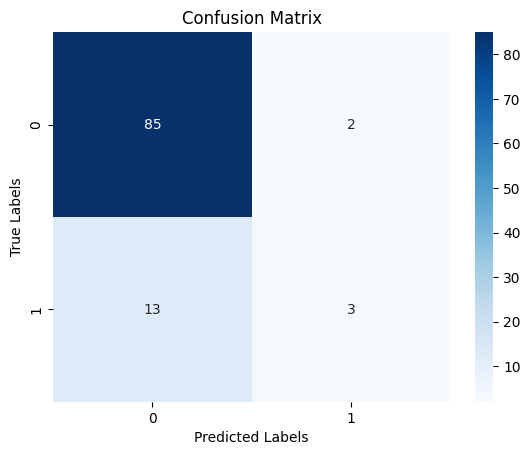

In [126]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction2)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

Decision Tree

In [127]:
#Decision Tree 
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state = 0,criterion = "entropy")
tree.fit(x_train, y_train)
prediction3 = classifier.predict(x_test)

In [128]:
prediction3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [129]:
confusion_matrix(y_test,prediction3)

array([[85,  2],
       [13,  3]])

In [130]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction3)
precision = precision_score(y_test, prediction3)
recall = recall_score(y_test, prediction3)
f1 = f1_score(y_test, prediction3)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8543689320388349
Precision: 0.8673469387755102
Recall: 0.9770114942528736
F1 score: 0.918918918918919


In [131]:
accuracy_score(y_test,prediction3)

0.8543689320388349

In [132]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction3, average = None)

array([0.86734694, 0.6       ])

In [133]:
recall_score(y_test, prediction3, average = None)

array([0.97701149, 0.1875    ])

In [134]:
f1_score(y_test, prediction3, average = None)

array([0.91891892, 0.28571429])

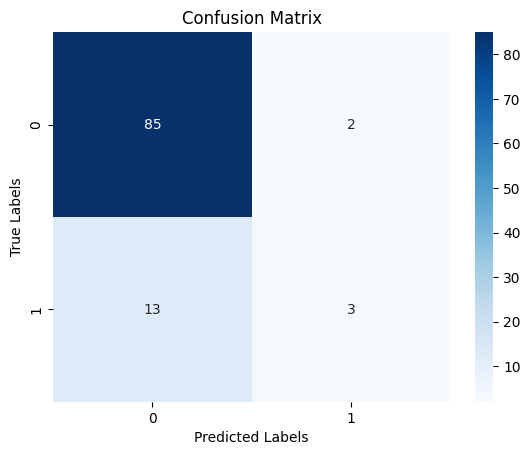

In [135]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction3)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

SVM

In [136]:
#Support Vector Machine
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
svm = OneVsRestClassifier(BaggingClassifier(SVC(C=10,kernel='rbf',random_state=9,probability=True),n_jobs=-1))
svm.fit(x_train, y_train)
prediction4 = svm.predict(x_test)

In [137]:
confusion_matrix(y_test,prediction4)

array([[87,  0],
       [16,  0]])

In [138]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction4)
precision = precision_score(y_test, prediction4)
recall = recall_score(y_test, prediction4)
f1 = f1_score(y_test, prediction4)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8446601941747572
Precision: 0.8446601941747572
Recall: 1.0
F1 score: 0.9157894736842105


In [139]:
accuracy_score(y_test,prediction4)

0.8446601941747572

In [140]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction4, average = None)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([0.84466019, 0.        ])

In [141]:
recall_score(y_test, prediction4, average = None)

array([1., 0.])

In [142]:
f1_score(y_test, prediction4, average = None)

array([0.91578947, 0.        ])

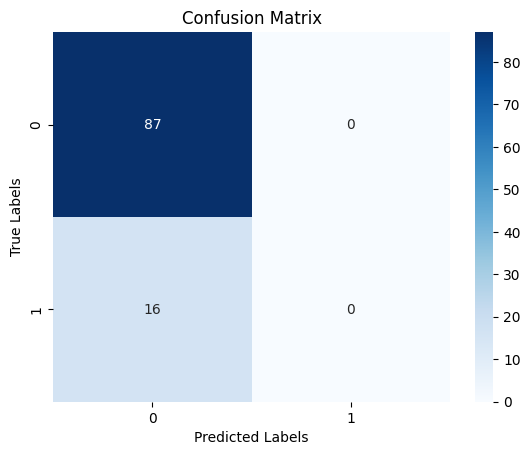

In [143]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction4)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

Naive Bayes

In [144]:
from sklearn.naive_bayes import GaussianNB
nbcla = GaussianNB()
nbcla.fit(x_train, y_train)
prediction5 = nbcla.predict(x_test)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [145]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction5)

array([[81,  6],
       [ 8,  8]])

In [146]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction5)
precision = precision_score(y_test, prediction5)
recall = recall_score(y_test, prediction5)
f1 = f1_score(y_test, prediction5)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8640776699029126
Precision: 0.9101123595505618
Recall: 0.9310344827586207
F1 score: 0.9204545454545454


In [147]:
accuracy_score(y_test,prediction5)

0.8640776699029126

In [148]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction5, average = None)

array([0.91011236, 0.57142857])

In [149]:
recall_score(y_test, prediction5, average = None)

array([0.93103448, 0.5       ])

In [150]:
f1_score(y_test, prediction5, average = None)

array([0.92045455, 0.53333333])

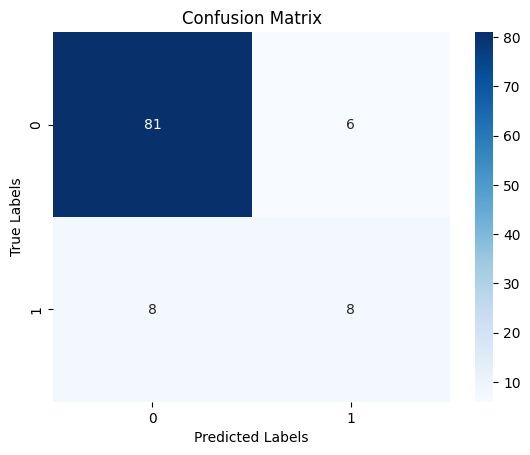

In [151]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction5)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

RANDOM FOREST

In [152]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using training dataset
rf_classifier.fit(x_train, y_train)

# Make predictions on test dataset
prediction6 = rf_classifier.predict(x_test)

# Evaluate the accuracy of the model
#accuracy = rf_classifier.score(x_test, y_test)
#print("Accuracy:", accuracy)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [153]:
confusion_matrix(y_test,prediction6)

array([[85,  2],
       [ 9,  7]])

In [154]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction6)
precision = precision_score(y_test, prediction6)
recall = recall_score(y_test, prediction6)
f1 = f1_score(y_test, prediction6)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8932038834951457
Precision: 0.9042553191489362
Recall: 0.9770114942528736
F1 score: 0.9392265193370166


In [155]:
accuracy_score(y_test,prediction6)

0.8932038834951457

In [156]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction6, average = None)

array([0.90425532, 0.77777778])

In [157]:
recall_score(y_test, prediction6, average = None)

array([0.97701149, 0.4375    ])

In [158]:
f1_score(y_test, prediction6, average = None)

array([0.93922652, 0.56      ])

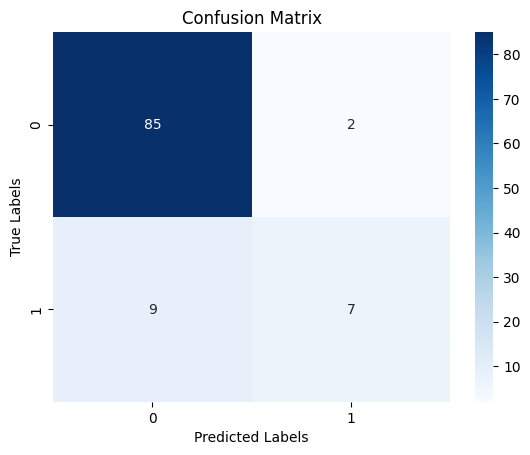

In [159]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction6)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

========================================================================================================================

In [160]:
#Finding Correlation
cn=lung_data.corr()
cn

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
GENDER,1.000000,-0.021306,-0.036277,0.212959,0.152127,0.275564,0.204606,0.083560,-0.154251,-0.141207,-0.454268,-0.133303,0.064911,0.078161,-0.362958,0.067254
AGE,-0.021306,1.000000,-0.084475,0.005205,0.053170,0.018685,-0.012642,0.012614,0.027990,0.055011,0.058985,0.169950,-0.017513,-0.001270,-0.018104,-0.089465
SMOKING,-0.036277,-0.084475,1.000000,-0.014585,0.160267,-0.042822,-0.141522,-0.029575,0.001913,-0.129426,-0.050623,-0.129471,0.061264,0.030718,0.120117,-0.058179
YELLOW_FINGERS,0.212959,0.005205,-0.014585,1.000000,0.565829,0.323083,0.041122,-0.118058,-0.144300,-0.078515,-0.289025,-0.012640,-0.105944,0.345904,-0.104829,-0.181339
ANXIETY,0.152127,0.053170,0.160267,0.565829,1.000000,0.216841,-0.009678,-0.188538,-0.165750,-0.191807,-0.165750,-0.225644,-0.144077,0.489403,-0.113634,-0.144947
PEER_PRESSURE,0.275564,0.018685,-0.042822,0.323083,0.216841,1.000000,0.048515,0.078148,-0.081800,-0.068771,-0.159973,-0.089019,-0.220175,0.366590,-0.094828,-0.186388
CHRONIC DISEASE,0.204606,-0.012642,-0.141522,0.041122,-0.009678,0.048515,1.000000,-0.110529,0.106386,-0.049967,0.002150,-0.175287,-0.026459,0.075176,-0.036938,-0.110891
FATIGUE,0.083560,0.012614,-0.029575,-0.118058,-0.188538,0.078148,-0.110529,1.000000,0.003056,0.141937,-0.191377,0.146856,0.441745,-0.132790,-0.010832,-0.150673
ALLERGY,-0.154251,0.027990,0.001913,-0.144300,-0.165750,-0.081800,0.106386,0.003056,1.000000,0.173867,0.344339,0.189524,-0.030056,-0.061508,0.239433,-0.327766
WHEEZING,-0.141207,0.055011,-0.129426,-0.078515,-0.191807,-0.068771,-0.049967,0.141937,0.173867,1.000000,0.265659,0.374265,0.037834,0.069027,0.147640,-0.249300


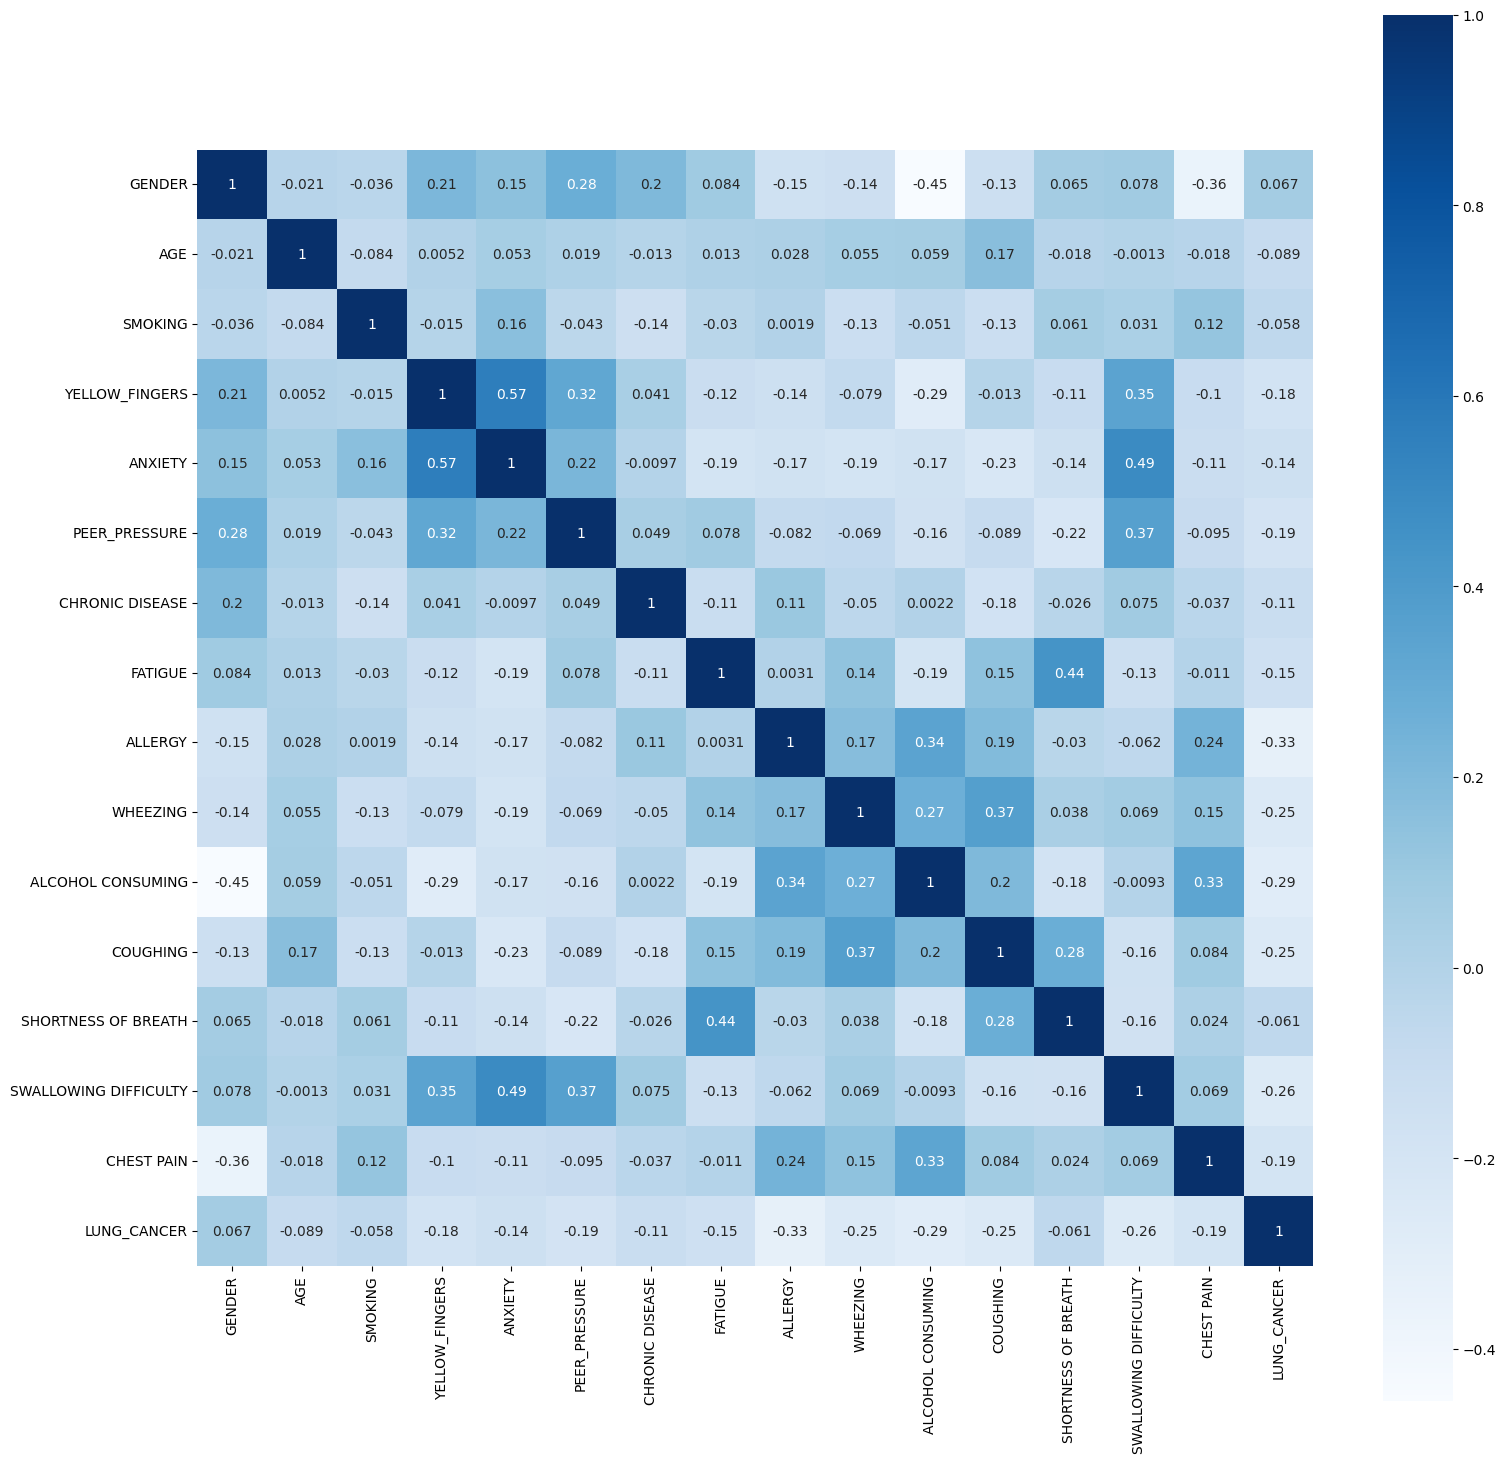

In [161]:
#Correlation 
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap="Blues",annot=True, square=True)
plt.show()

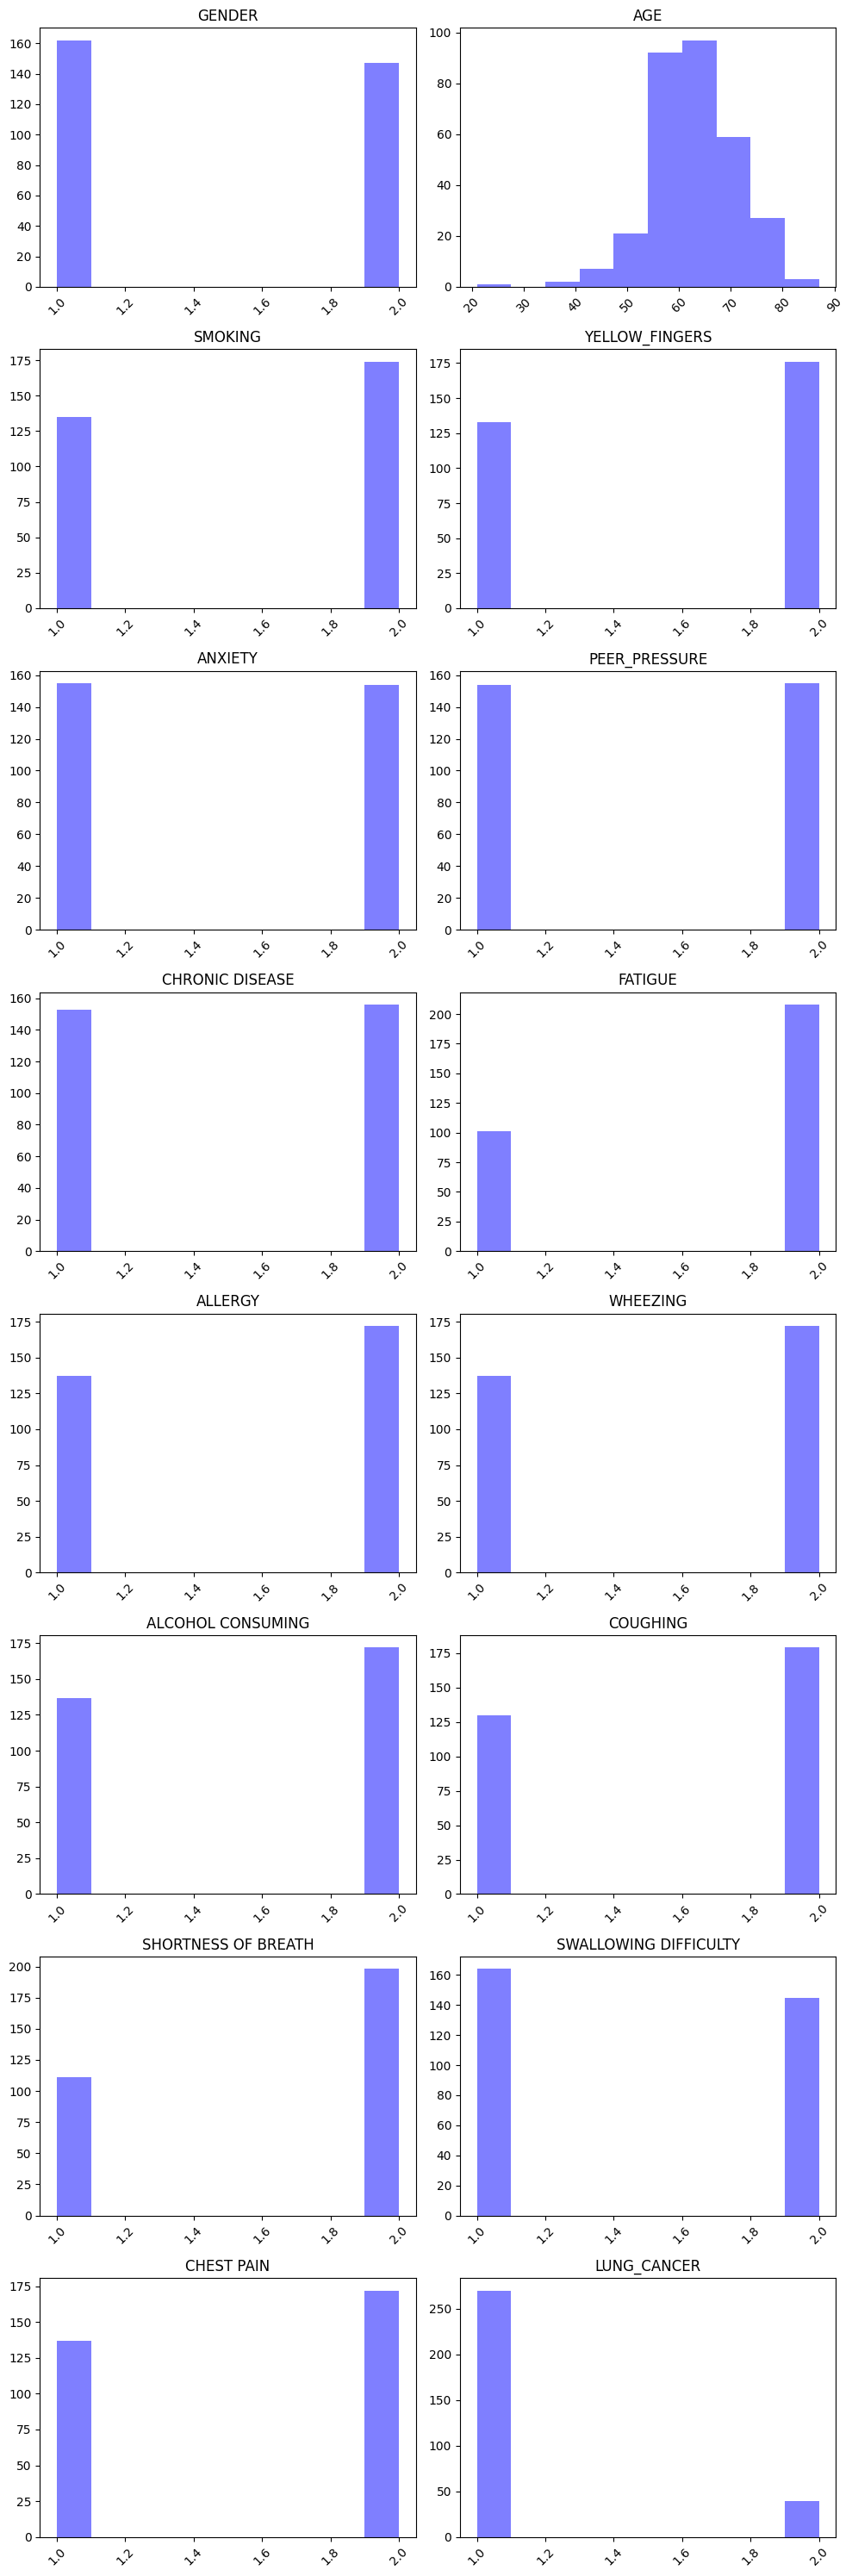

In [162]:
num_list = list(lung_data.columns)

fig = plt.figure(figsize=(10,30))

for i in range(len(num_list)):
    plt.subplot(8,2,i+1)
    plt.title(num_list[i])
    plt.xticks(rotation=45)
    plt.hist(lung_data[num_list[i]],color='blue',alpha=0.5)

plt.tight_layout()